# Predicting Breast Cancer Diagnosis


### Step 1: Understand the Problem

🎯 Objective

Predict whether a tumor is:

- Malignant (M)
- Benign (B)

using cell nucleus measurements.

This is a binary classification problem, so we use:

✅ Logistic Regression (not linear regression)

### Step 2: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

## Step 3: Read the data

In [23]:
bc_source = 'https://raw.githubusercontent.com/HackBio-Internship/2025_project_collection/refs/heads/main/Python/Dataset/data-3.csv'

In [24]:
bc = pd.read_csv(bc_source, index_col=0)

In [25]:
bc.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [26]:
bc = bc.drop(columns=["Unnamed: 32"])

In [27]:
bc.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [31]:
bc.shape

(569, 31)

<Axes: xlabel='count', ylabel='diagnosis'>

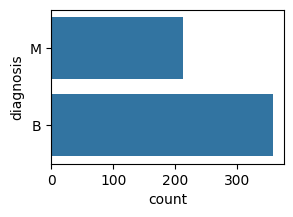

In [30]:
plt.figure(figsize=(3,2))
sns.countplot(data = bc['diagnosis'])

## Step 4: Encode the target variable

In [7]:
bc["diagnosis"] = bc["diagnosis"].map({"M": 1, "B": 0})

Now:
- 1 = Malignant
- 0 = Benign

In [8]:
bc.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Step 5: Train/Test Split

In [9]:
y = bc["diagnosis"]
X = bc.drop("diagnosis", axis=1)

In [10]:
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [11]:
y

id
842302      1
842517      1
84300903    1
84348301    1
84358402    1
           ..
926424      1
926682      1
926954      1
927241      1
92751       0
Name: diagnosis, Length: 569, dtype: int64

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## Step 6: Scale the features

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
X_test_scaled

array([[-0.48313229, -0.13285829, -0.46029654, ..., -0.19338258,
         0.21048039,  0.22648723],
       [ 1.34906186,  0.51103428,  1.29204314, ...,  1.01968394,
        -0.53341696, -1.00866239],
       [ 0.36358494,  0.0762286 ,  0.38928522, ...,  0.58868486,
        -0.07390369, -0.19132599],
       ...,
       [-1.20977993, -0.2611616 , -1.1400444 , ..., -0.23099704,
        -0.4321955 ,  1.86687566],
       [-0.10083521,  1.26659826,  0.00303674, ...,  0.59965574,
         1.23394176,  1.98690408],
       [-0.36419542, -1.19967661, -0.30118031, ...,  0.66234652,
        -0.39202826,  1.95832589]], shape=(171, 30))

In [33]:
X_test_scaled.shape

(171, 30)

## Step 7: Baseline Model (All 30 Predictors)

Let’s first train using all predictors.

In [14]:
model_full = LogisticRegression(max_iter=5000)
model_full.fit(X_train_scaled, y_train)

y_pred_full = model_full.predict(X_test_scaled)

print("Accuracy (All Features):", accuracy_score(y_test, y_pred_full))
print(classification_report(y_test, y_pred_full))

Accuracy (All Features): 0.9824561403508771
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       108
           1       0.97      0.98      0.98        63

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



Per class (0 and 1):
 - precision → Out of what the model predicted as positive, how many were actually correct? (correctness)
 - recall → Out of all real positive cases, how many did the model find? (completeness)
 - f1-score → Balance between precision & recall (higher = better overall)

$$
F_1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}
$$

 - support → Number of true samples of that class

## Step 8: Why Feature Selection Matters

In real biology:
- You will have thousands of genes
- Millions of SNPs
- Hundreds of biomarkers

Using all predictors:
- Increases noise
- Reduces interpretability
- Increases overfitting risk
- Slows computation

We now demonstrate how to reduce the excess features.

In [15]:
selector = SelectKBest(score_func=f_classif, k=5)

X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['perimeter_mean', 'concave points_mean', 'radius_worst',
       'perimeter_worst', 'concave points_worst'],
      dtype='object')


### 🚧 Are these biologically meaningful morphological feature in cancer diagnosis?

In [16]:
model_selected = LogisticRegression(max_iter=5000)
model_selected.fit(X_train_selected, y_train)

y_pred_selected = model_selected.predict(X_test_selected)

print("Accuracy (Selected Features):", accuracy_score(y_test, y_pred_selected))
print(classification_report(y_test, y_pred_selected))

Accuracy (Selected Features): 0.9649122807017544
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       108
           1       0.95      0.95      0.95        63

    accuracy                           0.96       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



#### Key Observation

Very often:

Accuracy remains almost the same with just 5 features!

This demonstrates:

- ✔ Many features were redundant
- ✔ A smaller model can perform equally well
- ✔ Interpretability improves dramatically

In [17]:
print("Accuracy with 30 features:", accuracy_score(y_test, y_pred_full))
print("Accuracy with 5 features:", accuracy_score(y_test, y_pred_selected))

Accuracy with 30 features: 0.9824561403508771
Accuracy with 5 features: 0.9649122807017544


### 🧠 Biological Interpretation

The top features often relate to:
- Tumor size (radius, area)
- Irregularity (concave points)
- Shape distortion

These are clinically meaningful indicators of malignancy.

### L1 Regularization (Automatic feature selection)

In [18]:
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=5000)
lasso_model.fit(X_train_scaled, y_train)

important_features = X.columns[lasso_model.coef_[0] != 0]

print("Features selected by L1 regularization:")
print(important_features)

Features selected by L1 regularization:
Index(['compactness_mean', 'concave points_mean', 'symmetry_mean', 'radius_se',
       'texture_se', 'smoothness_se', 'compactness_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst', 'area_worst',
       'smoothness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst'],
      dtype='object')


### Visualizations

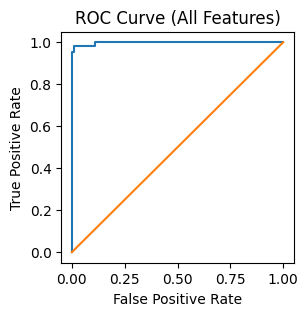

AUC Score: 0.9979423868312757


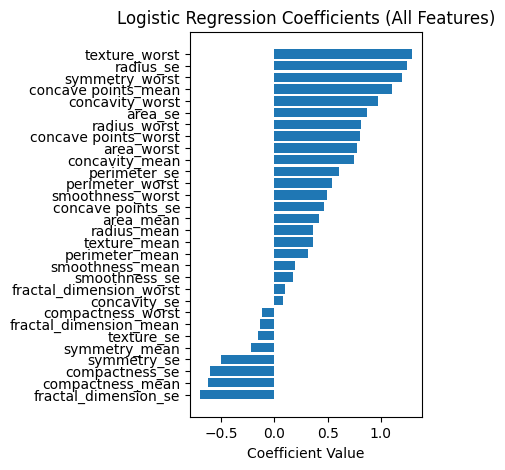

In [19]:


y_pred = model_full.predict(X_test_scaled)
y_prob = model_full.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(3,3))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Features)")
plt.show()

print("AUC Score:", roc_auc)

# ---- Coefficient Plot ----
coefficients = pd.Series(model_full.coef_[0], index=X.columns)
coefficients_sorted = coefficients.sort_values()

plt.figure(figsize=(3,5))
plt.barh(coefficients_sorted.index, coefficients_sorted.values)
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Coefficients (All Features)")
plt.show()